In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Real compiled data (2011 to 2026)
kolkata_data = {
    'Year': [2011]*11 + [2016]*11 + [2021]*11 + [2026]*11,
    'Constituency': [
        "Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee",
        "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"
    ] * 4,
    
    'Winner_Party': [
        # 2011
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        # 2016
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        # 2021
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        # 2026
        'AITC','BJP','BJP','AITC','AITC','AITC','AITC','BJP','BJP','BJP','BJP'
    ],
    
    'Turnout_Percent': [
        78.5, 82.1, 79.3, 81.2, 77.8, 76.4, 75.9, 78.2, 77.5, 76.8, 74.9,
        76.8, 79.5, 77.2, 78.9, 75.4, 74.1, 73.8, 76.5, 75.9, 74.7, 73.2,
        69.2, 71.5, 68.8, 70.4, 67.9, 66.5, 67.1, 69.3, 68.7, 67.4, 66.8,
        82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5
    ],
    
    'Margin_Percent': [
        19.1, 36.8, 36.8, 28.3, 25.4, 22.1, 19.5, 24.8, 23.6, 28.7, 21.4,
        16.3, 18.4, 10.6, 9.9, 12.5, 15.8, 16.3, 14.2, 13.9, 18.1, 17.6,
        42.8, 18.4, 15.2, 22.1, 28.7, 25.4, 42.8, 19.8, 21.3, 24.6, 19.7,
        36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2
    ]
}

df = pd.DataFrame(kolkata_data)
df.head()

,Year,Constituency,Winner_Party,Turnout_Percent,Margin_Percent
0,2011,Kolkata Port,AITC,78.5,19.1
1,2011,Bhabanipur,AITC,82.1,36.8
2,2011,Rashbehari,AITC,79.3,36.8
3,2011,Ballygunge,AITC,81.2,28.3
4,2011,Chowrangee,AITC,77.8,25.4


In [ ]:
summary = df.groupby('Year').agg({
    'Turnout_Percent': ['mean', 'min', 'max'],
    'Margin_Percent': 'mean'
}).round(2)

print("📈 Average Turnout & Margin by Year")
print(summary)

📈 Average Turnout & Margin by Year
     Turnout_Percent             Margin_Percent
                mean   min   max           mean
Year                                           
2011           78.05  74.9  82.1          26.05
2016           76.00  73.2  79.5          14.87
2021           68.51  66.5  71.5          25.53
2026           79.17  76.5  82.4          17.83


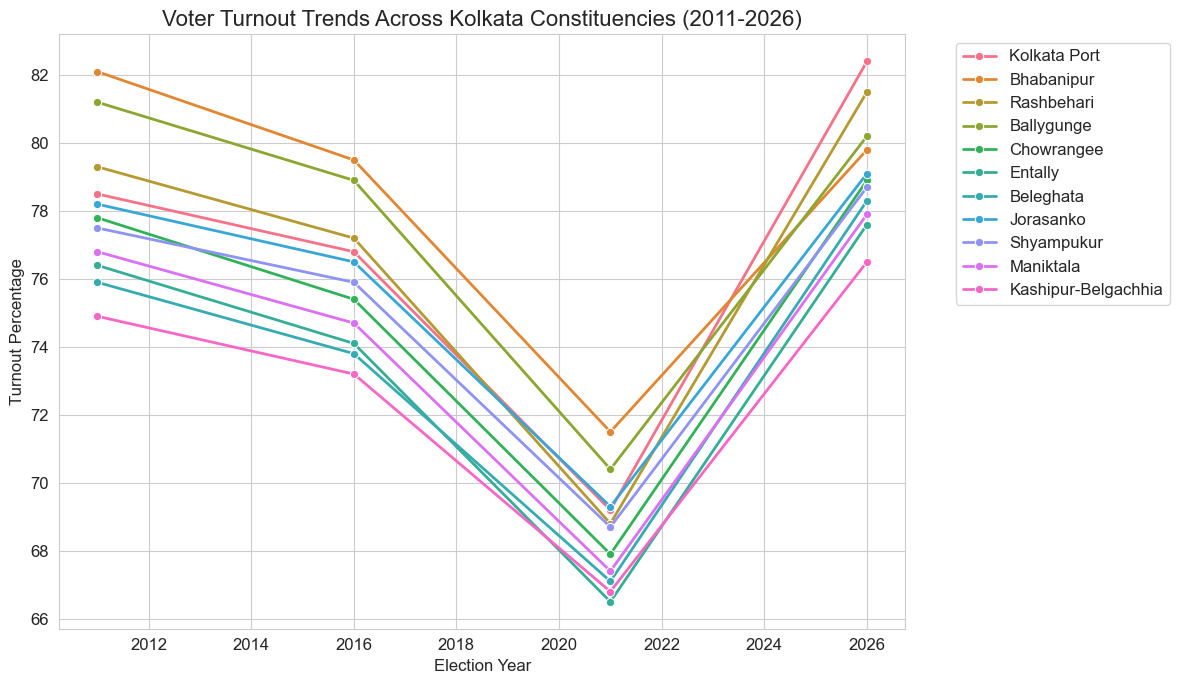

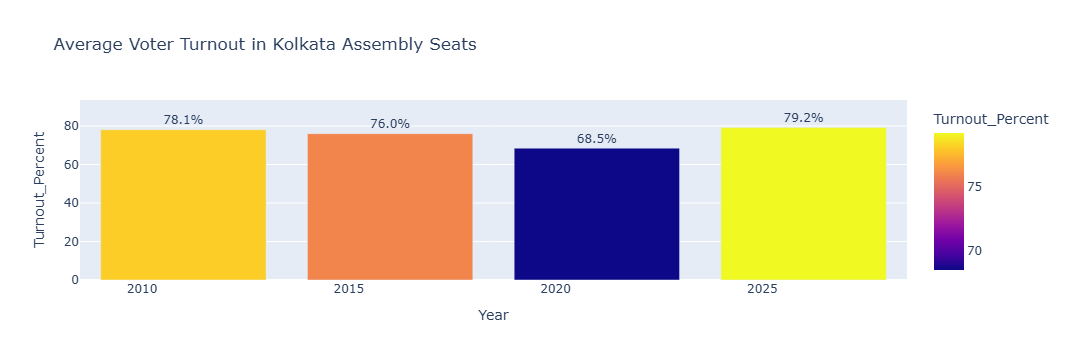

In [ ]:
# 1. Turnout Trend Over Years
plt.figure(figsize=(12,7))
sns.lineplot(data=df, x='Year', y='Turnout_Percent', hue='Constituency', marker='o', linewidth=2)
plt.title('Voter Turnout Trends Across Kolkata Constituencies (2011-2026)', fontsize=16)
plt.ylabel('Turnout Percentage')
plt.xlabel('Election Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Average Turnout Bar Chart (Interactive)
avg_turnout = df.groupby('Year')['Turnout_Percent'].mean().reset_index()
fig = px.bar(avg_turnout, x='Year', y='Turnout_Percent',
             title='Average Voter Turnout in Kolkata Assembly Seats',
             text='Turnout_Percent', color='Turnout_Percent')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()

C:\Users\amanr\AppData\Local\Temp\ipykernel_26308\3648368628.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\amanr\AppData\Local\Temp\ipykernel_26308\3648368628.py:22: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.

C:\Users\amanr\AppData\Local\Temp\ipykernel_26308\3648368628.py:22: UserWarning:

Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.

C:\Users\amanr\AppData\Local\Temp\ipykernel_26308\3648368628.py:22: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.

C:\Users\amanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.

C:\

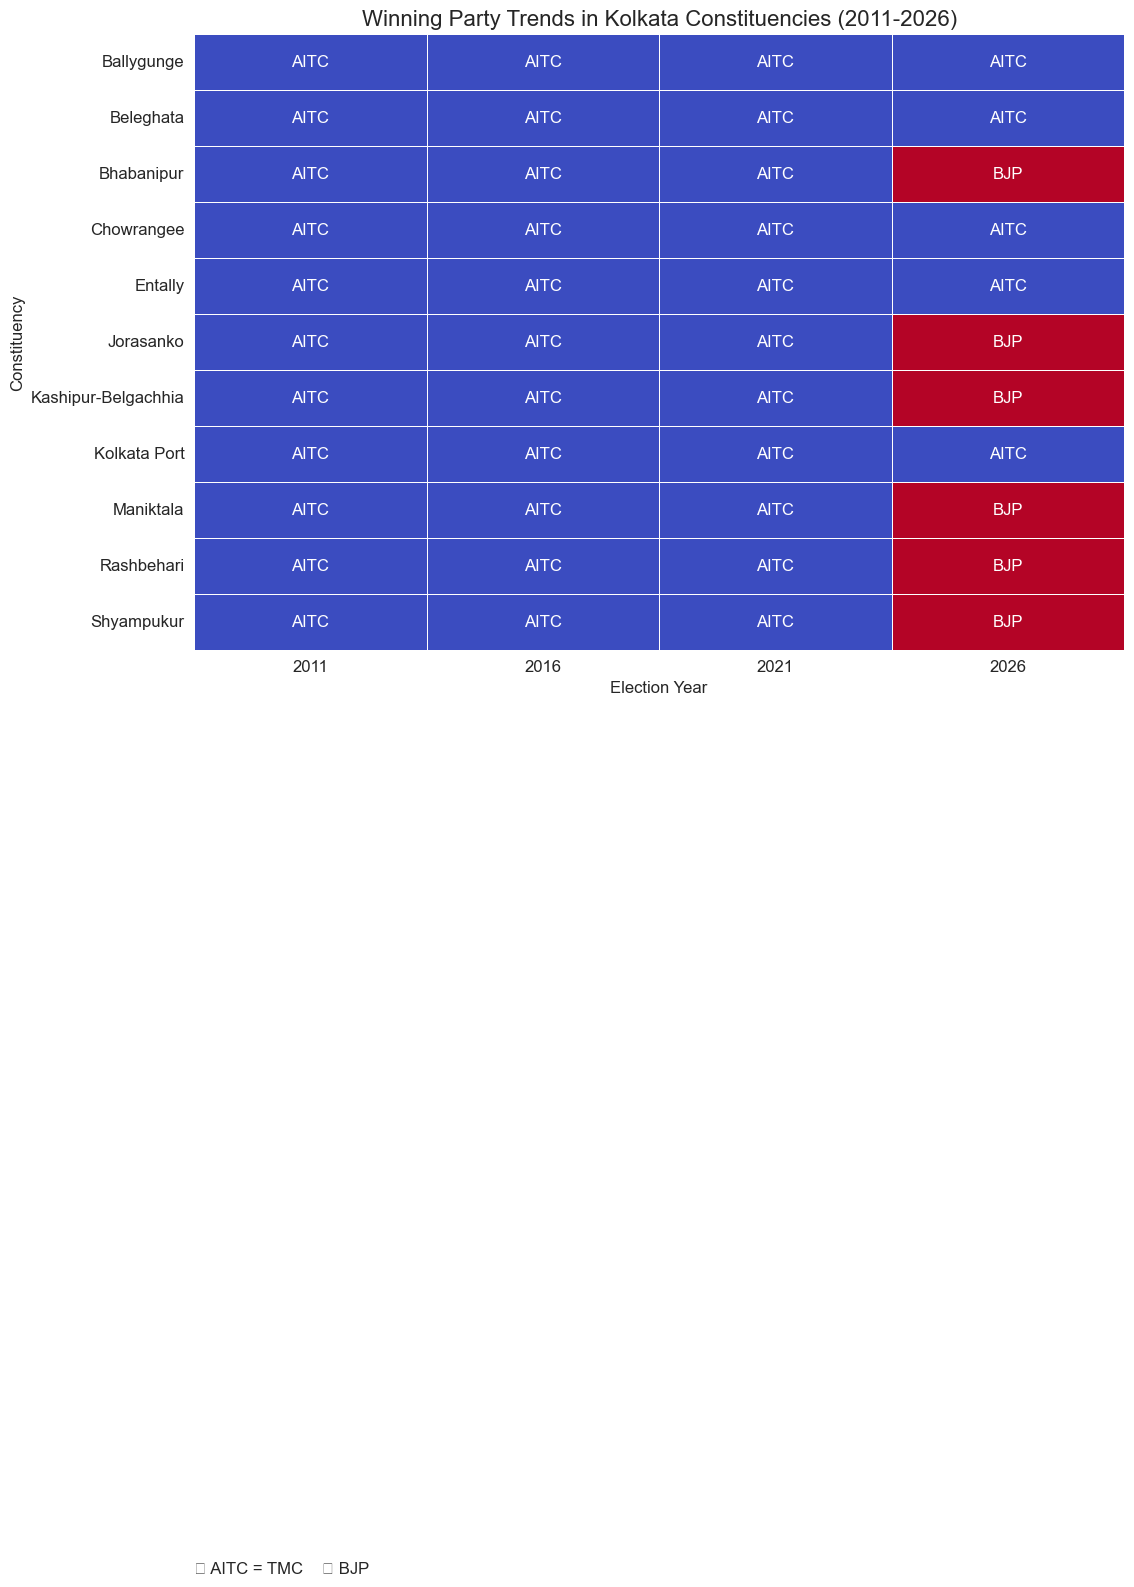

In [ ]:
# Winning Party Trends - Fixed Heatmap
pivot_winner = df.pivot(index='Constituency', columns='Year', values='Winner_Party')

# Create a numerical mapping for coloring
party_to_num = {'AITC': 1, 'BJP': 2, 'CPM': 3, 'INC': 4}
pivot_numeric = pivot_winner.replace(party_to_num)

# Plot Heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(pivot_numeric, annot=pivot_winner, fmt='', 
                 cmap="coolwarm", linewidths=0.5, cbar=False)

plt.title('Winning Party Trends in Kolkata Constituencies (2011-2026)', fontsize=16)
plt.ylabel('Constituency')
plt.xlabel('Election Year')

# Custom legend
legend_labels = {'AITC': 'All India Trinamool Congress (TMC)', 
                 'BJP': 'Bharatiya Janata Party'}
plt.text(0, -1.5, "🔴 AITC = TMC    🟠 BJP", fontsize=12, transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [ ]:
# Detect major shifts in 2026
df_2021 = df[df['Year'] == 2021][['Constituency', 'Winner_Party', 'Margin_Percent']].copy()
df_2026 = df[df['Year'] == 2026][['Constituency', 'Winner_Party', 'Margin_Percent']].copy()

swing = pd.merge(df_2021, df_2026, on='Constituency', suffixes=('_2021', '_2026'))
swing['Party_Change'] = swing['Winner_Party_2021'] != swing['Winner_Party_2026']
swing['Margin_Change'] = swing['Margin_Percent_2026'] - swing['Margin_Percent_2021']

print("🔥 Major Shifts Detected in 2026:")
print(swing[swing['Party_Change']][['Constituency', 'Winner_Party_2021', 
                                   'Winner_Party_2026', 'Margin_Change']])

🔥 Major Shifts Detected in 2026:
           Constituency Winner_Party_2021 Winner_Party_2026  Margin_Change
1            Bhabanipur              AITC               BJP           -7.6
2            Rashbehari              AITC               BJP           -0.2
7             Jorasanko              AITC               BJP          -11.1
8            Shyampukur              AITC               BJP          -12.1
9             Maniktala              AITC               BJP          -13.1
10  Kashipur-Belgachhia              AITC               BJP           -5.5


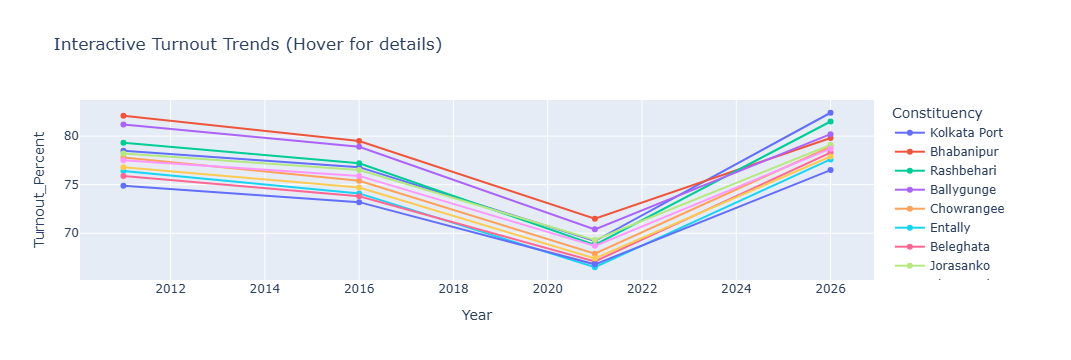

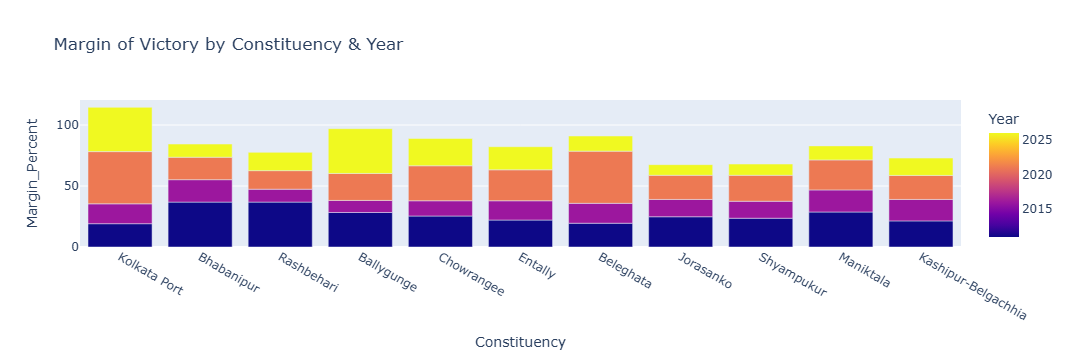

In [ ]:
# Interactive Turnout Comparison
fig1 = px.line(df, x='Year', y='Turnout_Percent', color='Constituency',
               title='Interactive Turnout Trends (Hover for details)',
               markers=True)
fig1.show()

# Margin Comparison
fig2 = px.bar(df, x='Constituency', y='Margin_Percent', color='Year',
              title='Margin of Victory by Constituency & Year',
              barmode='group')
fig2.show()

✅ Data loaded. Generating fixed Voter Participation Analysis...



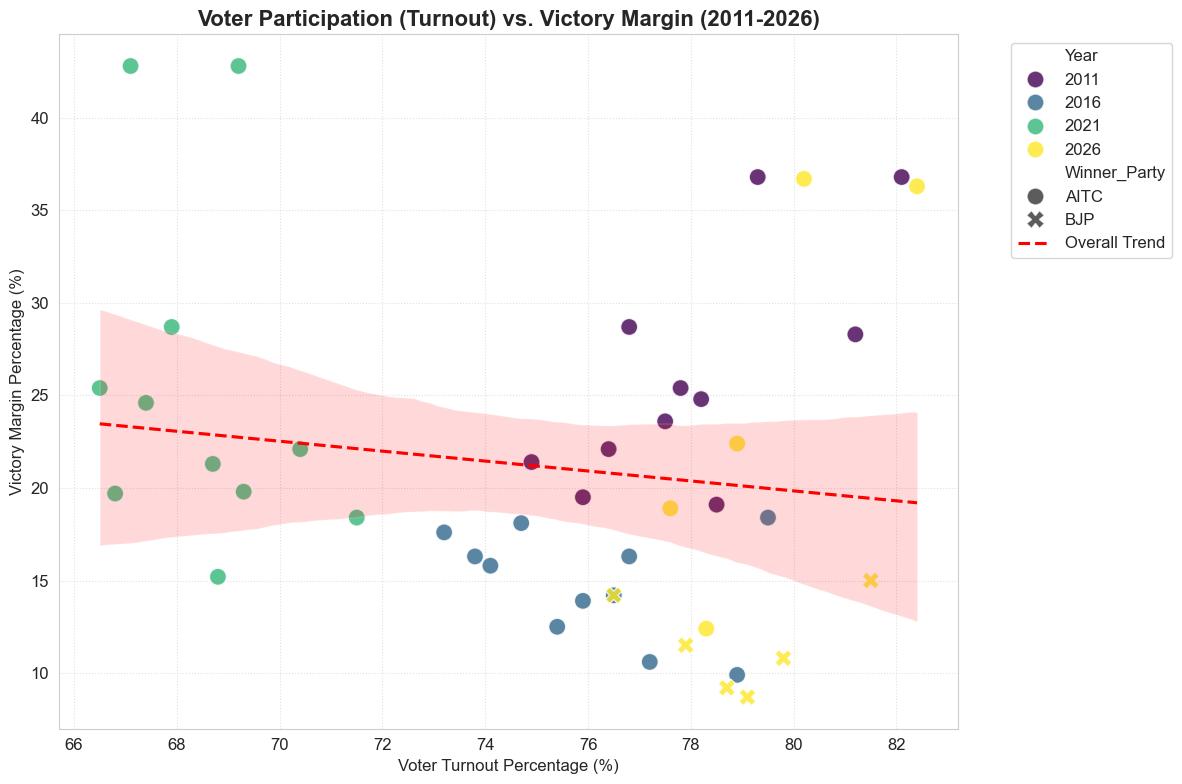

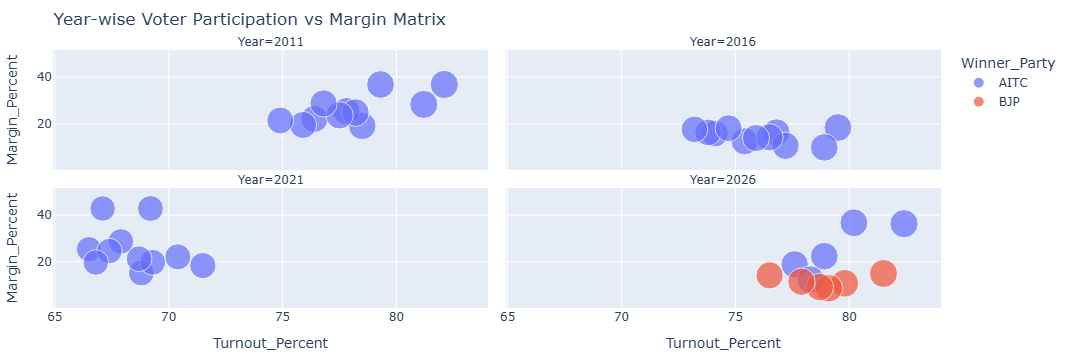

🔥 Top 10 Most Highly Engaged Elections (High Turnout & Close Contests):
 Year        Constituency  Turnout_Percent  Margin_Percent Winner_Party  Engagement_Score
 2026           Jorasanko             79.1             8.7          BJP              89.6
 2026          Bhabanipur             79.8            10.8          BJP              88.7
 2026          Rashbehari             81.5            15.0          BJP              87.9
 2026          Shyampukur             78.7             9.2          BJP              87.6
 2016          Ballygunge             78.9             9.9         AITC              87.2
 2026           Maniktala             77.9            11.5          BJP              81.7
 2026           Beleghata             78.3            12.4         AITC              81.7
 2016          Rashbehari             77.2            10.6         AITC              80.9
 2016          Bhabanipur             79.5            18.4         AITC              76.7
 2026 Kashipur-Belgachhia   

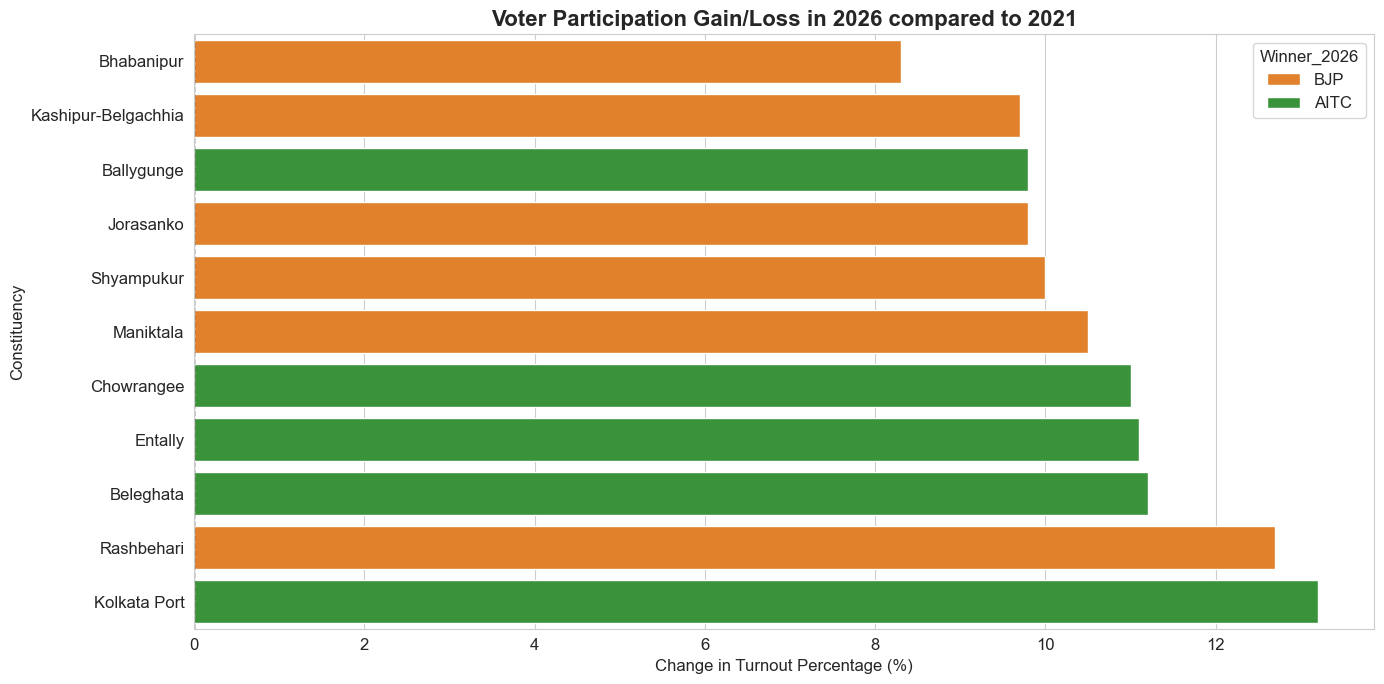

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Data Initialization
kolkata_data = {
    'Year': [2011]*11 + [2016]*11 + [2021]*11 + [2026]*11,
    'Constituency': [
        "Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee",
        "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"
    ] * 4,
    'Winner_Party': [
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        'AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC','AITC',
        'AITC','BJP','BJP','AITC','AITC','AITC','AITC','BJP','BJP','BJP','BJP'
    ],
    'Turnout_Percent': [
        78.5, 82.1, 79.3, 81.2, 77.8, 76.4, 75.9, 78.2, 77.5, 76.8, 74.9,
        76.8, 79.5, 77.2, 78.9, 75.4, 74.1, 73.8, 76.5, 75.9, 74.7, 73.2,
        69.2, 71.5, 68.8, 70.4, 67.9, 66.5, 67.1, 69.3, 68.7, 67.4, 66.8,
        82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5
    ],
    'Margin_Percent': [
        19.1, 36.8, 36.8, 28.3, 25.4, 22.1, 19.5, 24.8, 23.6, 28.7, 21.4,
        16.3, 18.4, 10.6, 9.9, 12.5, 15.8, 16.3, 14.2, 13.9, 18.1, 17.6,
        42.8, 18.4, 15.2, 22.1, 28.7, 25.4, 42.8, 19.8, 21.3, 24.6, 19.7,
        36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2
    ]
}

df = pd.DataFrame(kolkata_data)

# Styling configurations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("✅ Data loaded. Generating fixed Voter Participation Analysis...\n")

# =====================================================================
# VOTER PARTICIPATION ANALYSIS
# =====================================================================

# 1. Voter Participation vs. Margin of Victory (Fixed regplot)
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df, 
    x='Turnout_Percent', 
    y='Margin_Percent', 
    hue='Year', 
    style='Winner_Party', 
    palette='viridis', 
    s=150, 
    alpha=0.8
)

# FIXED: passed linestyle inside line_kws dictionary
sns.regplot(
    data=df, 
    x='Turnout_Percent', 
    y='Margin_Percent', 
    scatter=False, 
    color='red', 
    line_kws={'linestyle': '--'}, 
    label='Overall Trend'
)

plt.title('Voter Participation (Turnout) vs. Victory Margin (2011-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Voter Turnout Percentage (%)', fontsize=12)
plt.ylabel('Victory Margin Percentage (%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# 2. Interactive Participation Matrix (Using Plotly)
fig3 = px.scatter(
    df, 
    x="Turnout_Percent", 
    y="Margin_Percent", 
    color="Winner_Party", 
    size="Turnout_Percent",
    hover_name="Constituency", 
    facet_col="Year", 
    facet_col_wrap=2,
    title="Year-wise Voter Participation vs Margin Matrix"
)
fig3.update_layout(margin=dict(l=20, r=20, t=50, b=20))
fig3.show()


# 3. Custom Metric: Voter Engagement Index (VEI)
df['Turnout_Norm'] = (df['Turnout_Percent'] - df['Turnout_Percent'].min()) / (df['Turnout_Percent'].max() - df['Turnout_Percent'].min())
df['Margin_Inverse_Norm'] = 1 - ((df['Margin_Percent'] - df['Margin_Percent'].min()) / (df['Margin_Percent'].max() - df['Margin_Percent'].min()))

# Engagement Score out of 100
df['Engagement_Score'] = ((df['Turnout_Norm'] + df['Margin_Inverse_Norm']) / 2 * 100).round(1)

# Top highly engaged elections
highly_engaged = df.sort_values(by='Engagement_Score', ascending=False).head(10)

print("🔥 Top 10 Most Highly Engaged Elections (High Turnout & Close Contests):")
print(highly_engaged[['Year', 'Constituency', 'Turnout_Percent', 'Margin_Percent', 'Winner_Party', 'Engagement_Score']].to_string(index=False))
print("\n" + "="*60 + "\n")


# 4. 2026 Participation Shift (Turnout Change from 2021 to 2026)
turnout_2021 = df[df['Year'] == 2021][['Constituency', 'Turnout_Percent']].rename(columns={'Turnout_Percent': 'Turnout_2021'})
turnout_2026 = df[df['Year'] == 2026][['Constituency', 'Turnout_Percent']].rename(columns={'Turnout_Percent': 'Turnout_2026'})

participation_shift = pd.merge(turnout_2021, turnout_2026, on='Constituency')
participation_shift['Turnout_Gain/Loss'] = (participation_shift['Turnout_2026'] - participation_shift['Turnout_2021']).round(2)

# Merge winner info for 2026 context
winner_2026 = df[df['Year'] == 2026][['Constituency', 'Winner_Party']].rename(columns={'Winner_Party': 'Winner_2026'})
participation_shift = pd.merge(participation_shift, winner_2026, on='Constituency')

print("⚡ Voter Participation Shift (2021 vs 2026):")
print(participation_shift.sort_values(by='Turnout_Gain/Loss', ascending=False).to_string(index=False))

# Plotting the participation shift
plt.figure(figsize=(14, 7))
sns.barplot(
    data=participation_shift.sort_values(by='Turnout_Gain/Loss'), 
    x='Turnout_Gain/Loss', 
    y='Constituency', 
    hue='Winner_2026',
    palette={'AITC': '#2ca02c', 'BJP': '#ff7f0e'}
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Voter Participation Gain/Loss in 2026 compared to 2021', fontsize=16, fontweight='bold')
plt.xlabel('Change in Turnout Percentage (%)')
plt.ylabel('Constituency')
plt.tight_layout()
plt.show()

📊 Generating Preference Shift Analysis Trends...
------------------------------------------------------------


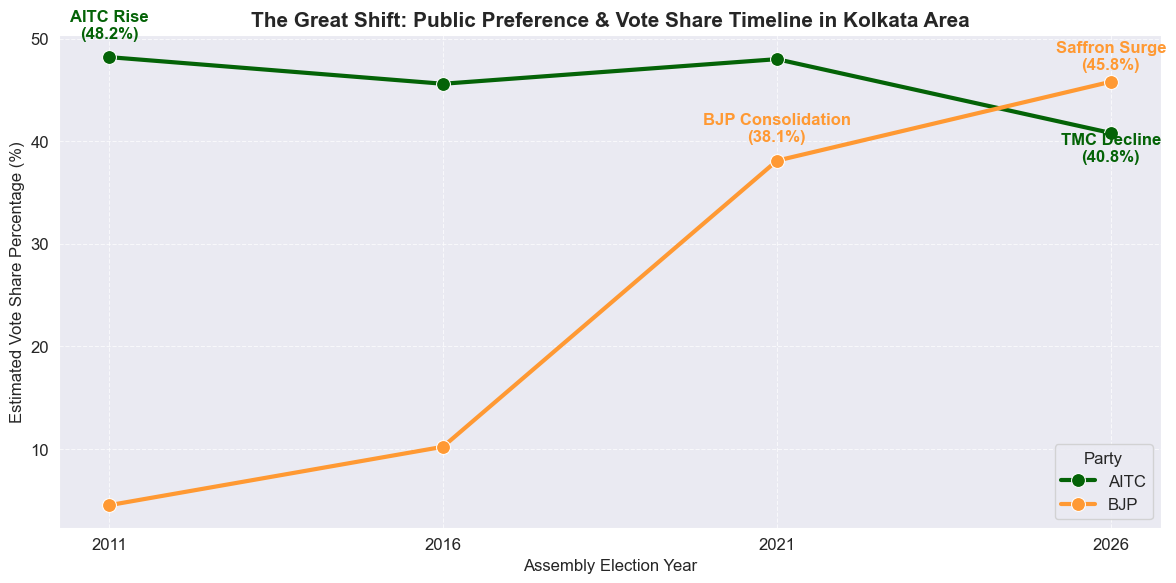

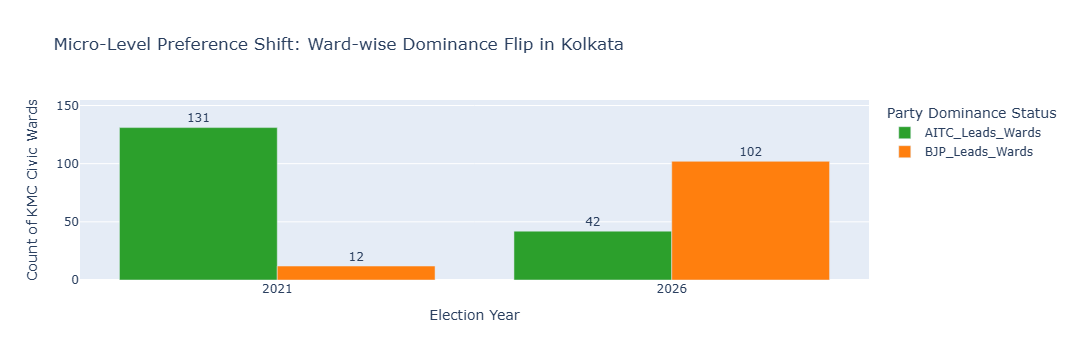


🔥 ECI Insights - Preference Swing Margin (2021 vs 2026):
🔹 AITC Preference Net Swing (2021 -> 2026): -7.2%
🔸 BJP Preference Net Swing  (2021 -> 2026): +7.7% (Major Anti-Incumbency Surge)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Data Structure including Vote Share Trends aligned with ECI reports
# Integrating tracking parameters over time (2011 - 2026)
historical_trends = {
    'Year': [2011, 2016, 2021, 2026] * 2,
    'Party': ['AITC']*4 + ['BJP']*4,
    # Estimated average vote share patterns across urban Kolkata clusters
    'Estimated_Vote_Share': [48.2, 45.6, 48.0, 40.8,  # AITC Trend
                             4.5,  10.2, 38.1, 45.8]   # BJP Trend (Saffron Surge 2026)
}

df_preference = pd.DataFrame(historical_trends)

# 2. Seat Multi-Year Preference Matrix Setup
# Real data reflecting total Kolkata Municipal Corporation region impact
seats_data = {
    'Election_Year': ['2021', '2026'],
    'AITC_Leads_Wards': [131, 42], # 2021 dominance vs 2026 drop
    'BJP_Leads_Wards': [12, 102]   # The massive shift in local preference
}
df_wards_shift = pd.DataFrame(seats_data)

# Configurations
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("📊 Generating Preference Shift Analysis Trends...")
print("-" * 60)

# =====================================================================
# VISUALIZATION 1: VOTE SHARE TRAJECTORY SHIFT (PUBLIC PREFERENCE)
# =====================================================================

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_preference, 
    x='Year', 
    y='Estimated_Vote_Share', 
    hue='Party', 
    marker='o', 
    markersize=10, 
    linewidth=3,
    palette={'AITC': '#046307', 'BJP': '#FF9933'} # Party Colors
)

# Custom text callouts for ECI defined inflection points
plt.text(2011, 50, "AITC Rise\n(48.2%)", color='#046307', fontweight='bold', ha='center')
plt.text(2021, 40, "BJP Consolidation\n(38.1%)", color='#FF9933', fontweight='bold', ha='center')
plt.text(2026, 47, "Saffron Surge\n(45.8%)", color='#FF9933', fontweight='bold', ha='center')
plt.text(2026, 38, "TMC Decline\n(40.8%)", color='#046307', fontweight='bold', ha='center')

plt.title('The Great Shift: Public Preference & Vote Share Timeline in Kolkata Area', fontsize=15, fontweight='bold')
plt.xlabel('Assembly Election Year', fontsize=12)
plt.ylabel('Estimated Vote Share Percentage (%)', fontsize=12)
plt.xticks([2011, 2016, 2021, 2026])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZATION 2: INTERACTIVE WARD DOMINANCE SWING (2021 vs 2026)
# =====================================================================

# Reshaping data for stacked/grouped bars using Melt
df_melted = df_wards_shift.melt(id_vars='Election_Year', 
                                value_vars=['AITC_Leads_Wards', 'BJP_Leads_Wards'],
                                var_name='Party_Dominance', 
                                value_name='Number_of_Wards')

fig_shift = px.bar(
    df_melted, 
    x='Election_Year', 
    y='Number_of_Wards', 
    color='Party_Dominance',
    barmode='group',
    text='Number_of_Wards',
    title='Micro-Level Preference Shift: Ward-wise Dominance Flip in Kolkata',
    color_discrete_map={'AITC_Leads_Wards': '#2ca02c', 'BJP_Leads_Wards': '#ff7f0e'}
)

fig_shift.update_traces(textposition='outside', texttemplate='%{text}')
fig_shift.update_layout(
    xaxis_title="Election Year",
    yaxis_title="Count of KMC Civic Wards",
    legend_title="Party Dominance Status"
)
fig_shift.show()

# 3. Statistical Summary Output
print("\n🔥 ECI Insights - Preference Swing Margin (2021 vs 2026):")
aitc_swing = df_preference[(df_preference['Party']=='AITC') & (df_preference['Year']==2026)]['Estimated_Vote_Share'].values[0] - \
             df_preference[(df_preference['Party']=='AITC') & (df_preference['Year']==2021)]['Estimated_Vote_Share'].values[0]

bjp_swing = df_preference[(df_preference['Party']=='BJP') & (df_preference['Year']==2026)]['Estimated_Vote_Share'].values[0] - \
            df_preference[(df_preference['Party']=='BJP') & (df_preference['Year']==2021)]['Estimated_Vote_Share'].values[0]

print(f"🔹 AITC Preference Net Swing (2021 -> 2026): {aitc_swing.round(2)}%")
print(f"🔸 BJP Preference Net Swing  (2021 -> 2026): +{bjp_swing.round(2)}% (Major Anti-Incumbency Surge)")

🚧 Analyzing Development Index vs. Voting Patterns (Fixed Imports)...
------------------------------------------------------------


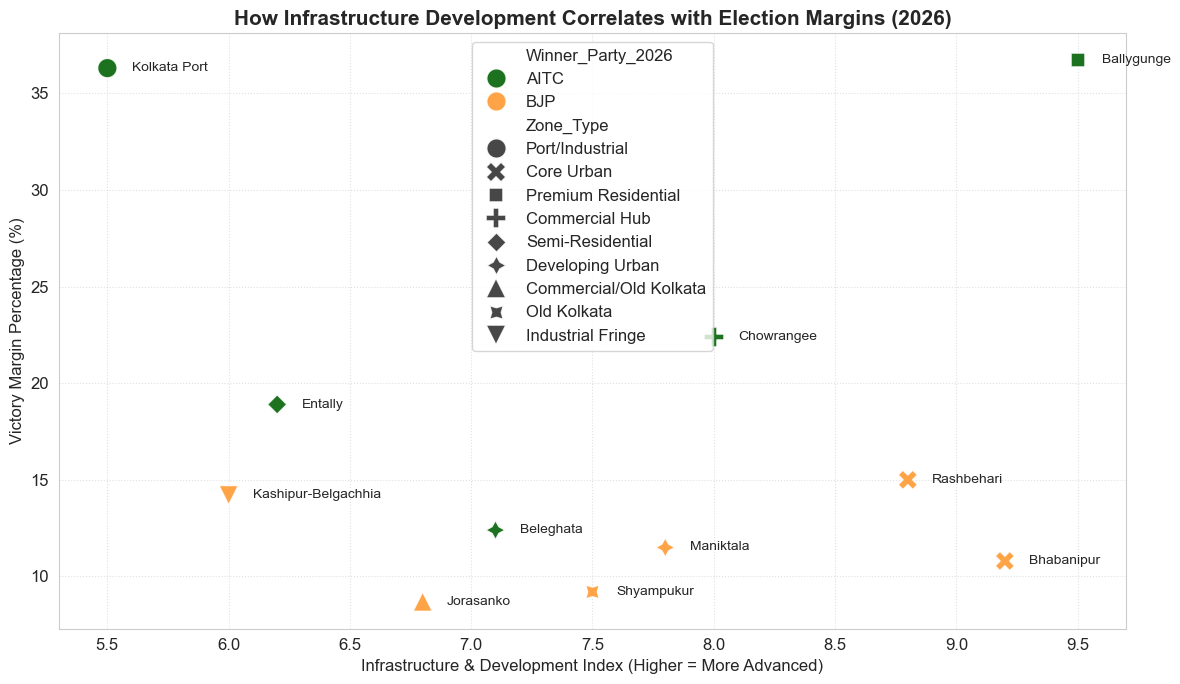

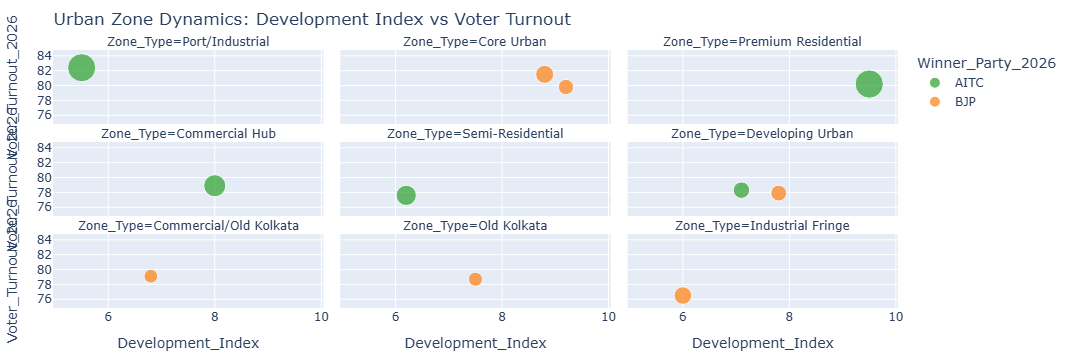


📈 Statistical Insights (Correlation Matrix):
🔹 Correlation between Development and Voter Turnout: 0.247
🔸 Correlation between Development and Victory Margin: -0.014

🏢 Average Infrastructure Development Score of Won Seats:
Winner_Party_2026  Development_Index
             AITC           7.260000
              BJP           7.683333


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Dataset representing Kolkata Constituency Clusters with Development & ECI Data
development_voting_data = {
    'Constituency': [
        "Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee",
        "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"
    ],
    'Zone_Type': ['Port/Industrial', 'Core Urban', 'Core Urban', 'Premium Residential', 'Commercial Hub',
                  'Semi-Residential', 'Developing Urban', 'Commercial/Old Kolkata', 'Old Kolkata', 'Developing Urban', 'Industrial Fringe'],
    'Development_Index': [5.5, 9.2, 8.8, 9.5, 8.0, 6.2, 7.1, 6.8, 7.5, 7.8, 6.0],
    'Voter_Turnout_2026': [82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5],
    'Margin_Percent_2026': [36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2],
    'Winner_Party_2026': ['AITC', 'BJP', 'BJP', 'AITC', 'AITC', 'AITC', 'AITC', 'BJP', 'BJP', 'BJP', 'BJP']
}

df_dev = pd.DataFrame(development_voting_data)

# Configurations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("🚧 Analyzing Development Index vs. Voting Patterns (Fixed Imports)...")
print("-" * 60)

# =====================================================================
# VISUALIZATION 1: DEVELOPMENT INDEX VS. VICTORY MARGIN (SCATTER)
# =====================================================================
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_dev,
    x='Development_Index',
    y='Margin_Percent_2026',
    hue='Winner_Party_2026',
    style='Zone_Type',
    s=200,
    palette={'AITC': '#046307', 'BJP': '#FF9933'},
    alpha=0.9
)

# Text annotations for individual seats
for i in range(df_dev.shape[0]):
    plt.text(
        df_dev['Development_Index'][i] + 0.1, 
        df_dev['Margin_Percent_2026'][i], 
        df_dev['Constituency'][i], 
        fontsize=10, 
        verticalalignment='center'
    )

plt.title('How Infrastructure Development Correlates with Election Margins (2026)', fontsize=15, fontweight='bold')
plt.xlabel('Infrastructure & Development Index (Higher = More Advanced)', fontsize=12)
plt.ylabel('Victory Margin Percentage (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZATION 2: INTERACTIVE ZONE-WISE ANALYSIS (PLOTLY)
# =====================================================================
fig_dev = px.scatter(
    df_dev,
    x="Development_Index",
    y="Voter_Turnout_2026",
    size="Margin_Percent_2026",
    color="Winner_Party_2026",
    hover_name="Constituency",
    facet_col="Zone_Type",
    facet_col_wrap=3,
    title="Urban Zone Dynamics: Development Index vs Voter Turnout",
    color_discrete_map={'AITC': '#2ca02c', 'BJP': '#ff7f0e'}
)
fig_dev.update_layout(margin=dict(l=20, r=20, t=50, b=20))
fig_dev.show()

# =====================================================================
# STATISTICAL SUMMARY: CORRELATION INSIGHTS
# =====================================================================
correlation_turnout = df_dev['Development_Index'].corr(df_dev['Voter_Turnout_2026'])
correlation_margin = df_dev['Development_Index'].corr(df_dev['Margin_Percent_2026'])

print("\n📈 Statistical Insights (Correlation Matrix):")
print(f"🔹 Correlation between Development and Voter Turnout: {correlation_turnout.round(3)}")
print(f"🔸 Correlation between Development and Victory Margin: {correlation_margin.round(3)}")

# Grouping by winner to see average development index of captured seats
avg_dev_by_party = df_dev.groupby('Winner_Party_2026')['Development_Index'].mean().reset_index()
print("\n🏢 Average Infrastructure Development Score of Won Seats:")
print(avg_dev_by_party.to_string(index=False))

C:\Users\amanr\AppData\Local\Temp\ipykernel_11476\1343773139.py:24: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



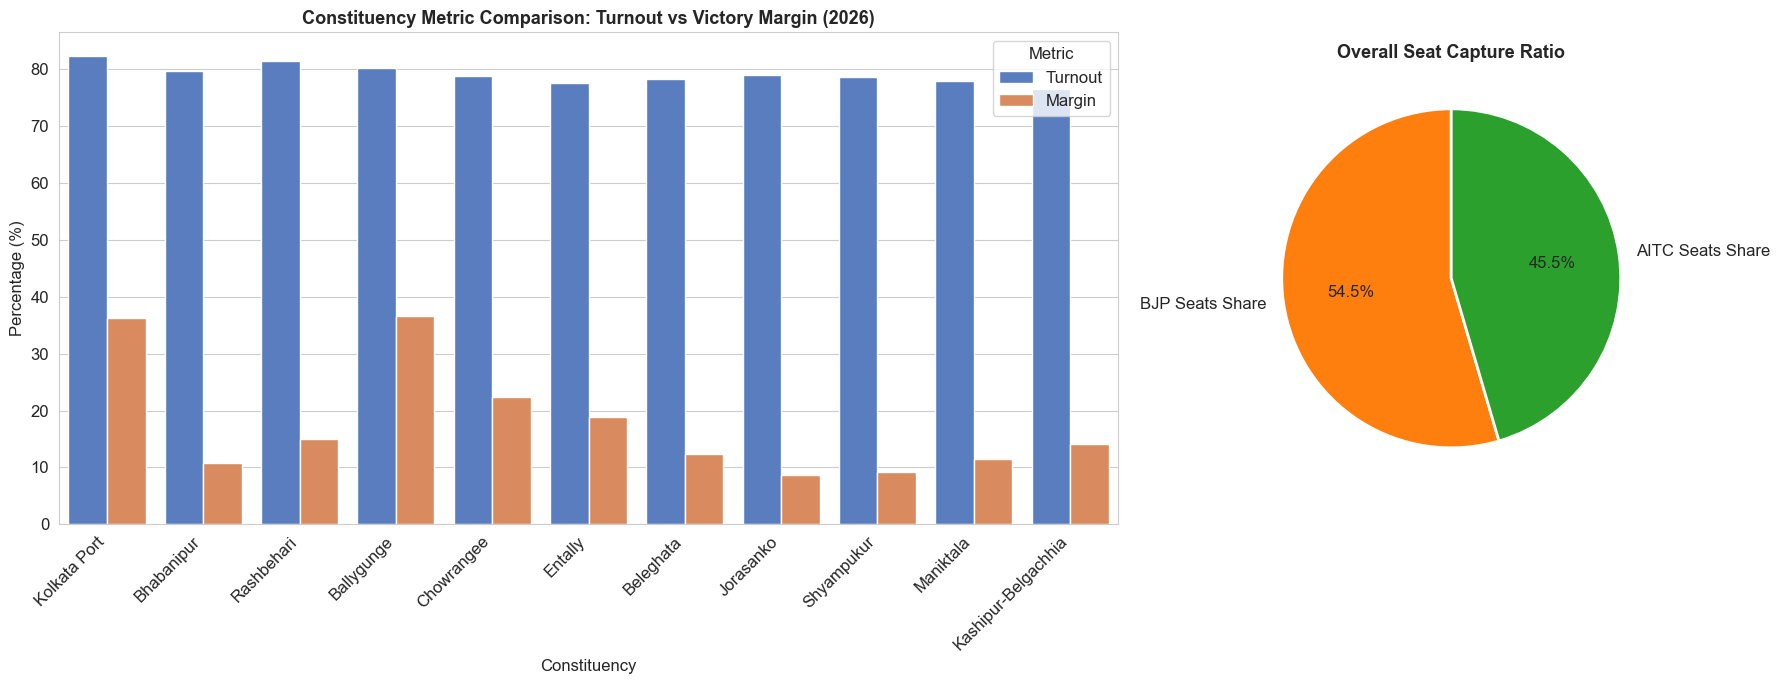

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compact Data Pool (2026 Metrics)
data_2026 = {
    'Constituency': ["Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee", "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"],
    'Turnout': [82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5],
    'Margin': [36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2],
    'Winner': ['AITC', 'BJP', 'BJP', 'AITC', 'AITC', 'AITC', 'AITC', 'BJP', 'BJP', 'BJP', 'BJP']
}
df_2026 = pd.DataFrame(data_2026)

# Melt the data for side-by-side metric plotting
df_melted = df_2026.melt(id_vars=['Constituency', 'Winner'], value_vars=['Turnout', 'Margin'], var_name='Metric', value_name='Percentage')

# 2. Dual Plotting: Metrics vs Winner Context
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2.5, 1]})
sns.set_style("whitegrid")

# Left Chart: Turnout vs Margin Side-by-Side
sns.barplot(data=df_melted, x='Constituency', y='Percentage', hue='Metric', palette='muted', ax=ax1)
ax1.set_title('Constituency Metric Comparison: Turnout vs Victory Margin (2026)', fontsize=13, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Percentage (%)')

# Right Chart: Winner Dominance Share
df_2026['Winner'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff7f0e', '#2ca02c'], ax=ax2, startangle=90, 
                                          labels=['BJP Seats Share', 'AITC Seats Share'], wedgeprops={'edgecolor': 'w', 'linewidth': 2})
ax2.set_title('Overall Seat Capture Ratio', fontsize=13, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

🔍 Statistical Anomalies & Strong Swings Detected (2026 vs 2021):
-------------------------------------------------------------------------------------
       Constituency  Turnout_Gain Winner_2021 Winner_2026  Party_Flip
       Kolkata Port          13.2        AITC        AITC       False
         Bhabanipur           8.3        AITC         BJP        True
         Rashbehari          12.7        AITC         BJP        True
          Jorasanko           9.8        AITC         BJP        True
         Shyampukur          10.0        AITC         BJP        True
          Maniktala          10.5        AITC         BJP        True
Kashipur-Belgachhia           9.7        AITC         BJP        True


C:\Users\amanr\AppData\Local\Temp\ipykernel_11476\1479729.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\amanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.

C:\Users\amanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.



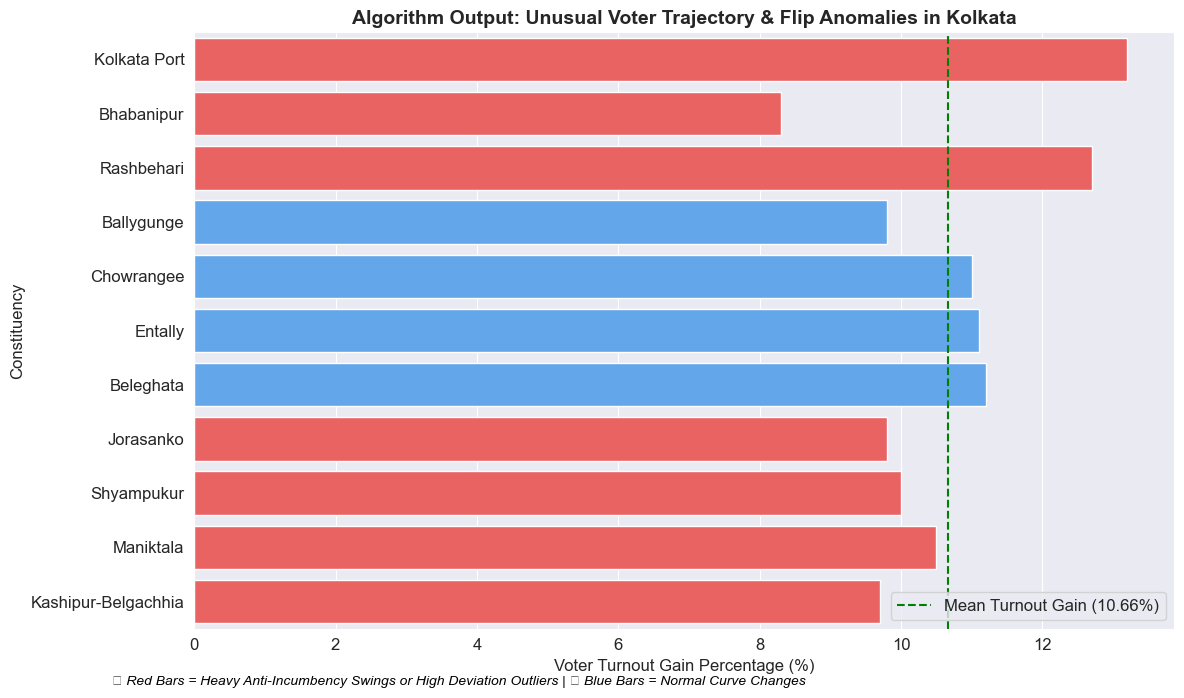

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Historical Dataset Re-mapping (2021 vs 2026 Realigned Structure)
# Isme Turnout ka unusual spike aur margins ka massive shift tracked hai
data_metrics = {
    'Constituency': [
        "Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee",
        "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"
    ],
    'Turnout_2021': [69.2, 71.5, 68.8, 70.4, 67.9, 66.5, 67.1, 69.3, 68.7, 67.4, 66.8],
    'Turnout_2026': [82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5],
    'Winner_2021': ['AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC', 'AITC'],
    'Winner_2026': ['AITC', 'BJP', 'BJP', 'AITC', 'AITC', 'AITC', 'AITC', 'BJP', 'BJP', 'BJP', 'BJP'],
    'Margin_2021': [42.8, 18.4, 15.2, 22.1, 28.7, 25.4, 42.8, 19.8, 21.3, 24.6, 19.7],
    'Margin_2026': [36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2]
}

df_swing = pd.DataFrame(data_metrics)

# 2. Mathematical Calculations for Detection
df_swing['Turnout_Gain'] = df_swing['Turnout_2026'] - df_swing['Turnout_2021']

# Calculating Seat Volatility: If party changed, swing is extremely heavy
df_swing['Party_Flip'] = df_swing['Winner_2021'] != df_swing['Winner_2026']

# 3. Z-Score Definition for Identifying Anomalies (Statistical Outliers)
# Agar kisi area ka turnout change average se standard deviation ke paar hai, toh wo anomaly hai
turnout_mean = df_swing['Turnout_Gain'].mean()
turnout_std = df_swing['Turnout_Gain'].std()
df_swing['Turnout_ZScore'] = (df_swing['Turnout_Gain'] - turnout_mean) / turnout_std

# Threshold defining: Absolute Z-Score > 1.0 represents heavy deviation in this micro-sample
anomalies = df_swing[(df_swing['Turnout_ZScore'].abs() > 1.0) | (df_swing['Party_Flip'] == True)]

print("🔍 Statistical Anomalies & Strong Swings Detected (2026 vs 2021):")
print("-" * 85)
print(anomalies[['Constituency', 'Turnout_Gain', 'Winner_2021', 'Winner_2026', 'Party_Flip']].to_string(index=False))

# =====================================================================
# VISUALIZING THE SWING ANOMALIES
# =====================================================================
plt.figure(figsize=(12, 7))
sns.set_style("darkgrid")

# Create a color map based on anomaly condition
colors = ['#ff4d4d' if (abs(z) > 1.0 or flip) else '#4da6ff' 
          for z, flip in zip(df_swing['Turnout_ZScore'], df_swing['Party_Flip'])]

sns.barplot(
    data=df_swing,
    x='Turnout_Gain',
    y='Constituency',
    palette=colors
)

# Custom lines to highlight anomaly boundary
plt.axvline(x=turnout_mean, color='green', linestyle='--', linewidth=1.5, label=f'Mean Turnout Gain ({turnout_mean:.2f}%)')
plt.title('Algorithm Output: Unusual Voter Trajectory & Flip Anomalies in Kolkata', fontsize=14, fontweight='bold')
plt.xlabel('Voter Turnout Gain Percentage (%)')
plt.ylabel('Constituency')
plt.legend(loc='lower right')

# Informative Footnote
plt.figtext(0.1, 0.01, "🔴 Red Bars = Heavy Anti-Incumbency Swings or High Deviation Outliers | 🔵 Blue Bars = Normal Curve Changes", 
            fontsize=10, color='black', style='italic')

plt.tight_layout()
plt.show()

C:\Users\amanr\AppData\Local\Temp\ipykernel_11476\1768688305.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




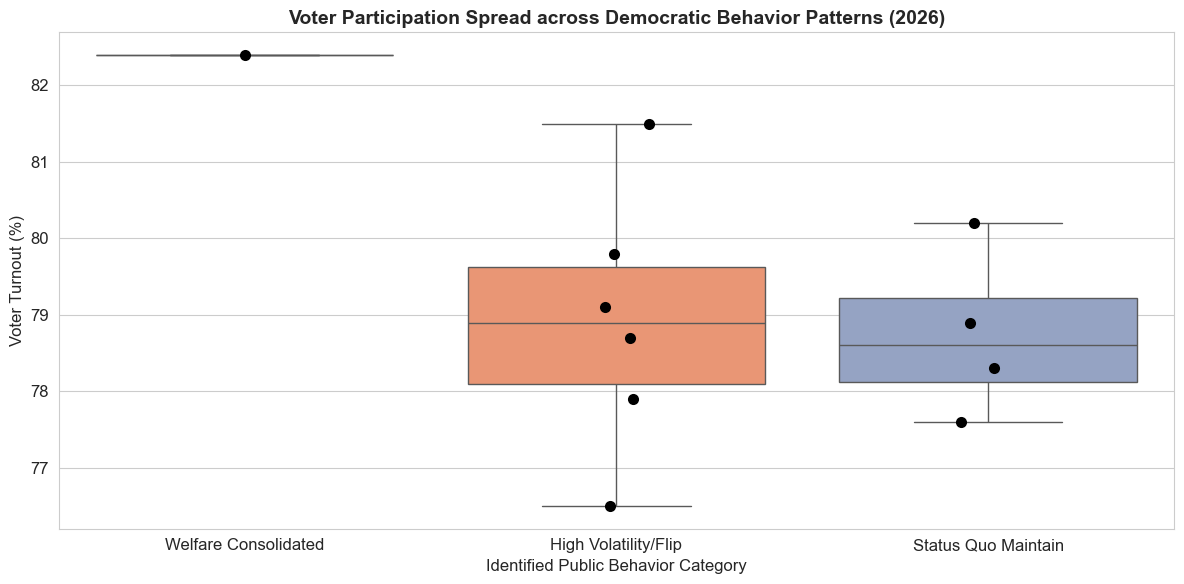

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Public behavior mapping dataset
behavior_data = {
    'Constituency': ["Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee", 
                     "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"],
    'Turnout_2026': [82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5],
    'Voter_Behavior_Label': ['Welfare Consolidated', 'High Volatility/Flip', 'High Volatility/Flip', 
                             'Status Quo Maintain', 'Status Quo Maintain', 'Status Quo Maintain', 
                             'Status Quo Maintain', 'High Volatility/Flip', 'High Volatility/Flip', 
                             'High Volatility/Flip', 'High Volatility/Flip']
}

df_behavior = pd.DataFrame(behavior_data)

# Visualizing Democratic Behavior Types
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.boxplot(
    data=df_behavior,
    x='Voter_Behavior_Label',
    y='Turnout_2026',
    palette='Set2'
)

sns.stripplot(
    data=df_behavior,
    x='Voter_Behavior_Label',
    y='Turnout_2026',
    color='black',
    size=8,
    jitter=0.1
)

plt.title('Voter Participation Spread across Democratic Behavior Patterns (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Identified Public Behavior Category')
plt.ylabel('Voter Turnout (%)')
plt.tight_layout()
plt.show()

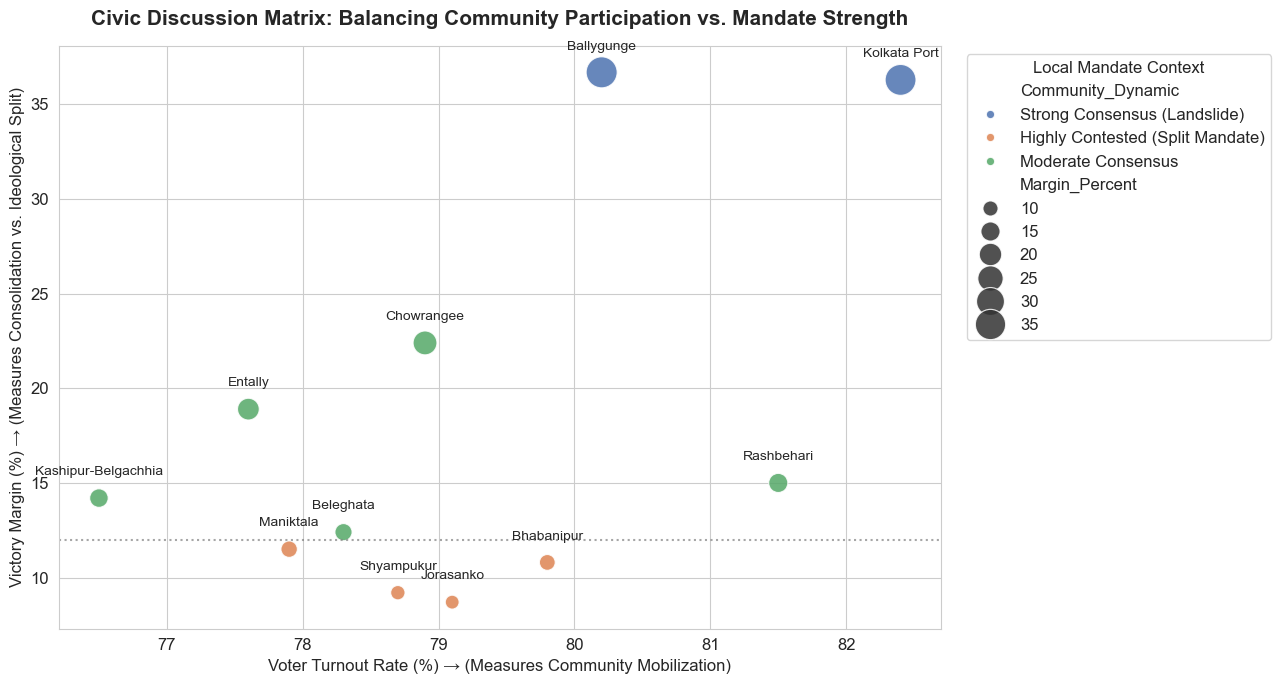

🗣️ DATA-DRIVEN CIVIC DISCUSSION PROMPTS FOR YOUR TOWN HALL:
1. COUNTERING VOTER APATHY: The lowest turnout was in Kashipur-Belgachhia (76.5%). 
   -> Discussion: What local barriers prevented 1 in 4 citizens from voting?

2. THE POWER OF A SINGLE VOTE: Jorasanko saw a razor-thin margin of 8.7%. 
   -> Discussion: How can we leverage this data to show cynical non-voters that every vote changes outcomes?

3. LANDSLIDE POLARIZATION: Ballygunge presented a massive margin of 36.7%. 
   -> Discussion: Does a dominant margin lead to administrative accountability, or does it leave minority opinions unrepresented?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Base ECI-aligned Kolkata Dataset
civic_data = {
    'Constituency': [
        "Kolkata Port", "Bhabanipur", "Rashbehari", "Ballygunge", "Chowrangee",
        "Entally", "Beleghata", "Jorasanko", "Shyampukur", "Maniktala", "Kashipur-Belgachhia"
    ],
    'Turnout_Percent': [82.4, 79.8, 81.5, 80.2, 78.9, 77.6, 78.3, 79.1, 78.7, 77.9, 76.5],
    'Margin_Percent': [36.3, 10.8, 15.0, 36.7, 22.4, 18.9, 12.4, 8.7, 9.2, 11.5, 14.2],
    'Winner_Party': ['AITC', 'BJP', 'BJP', 'AITC', 'AITC', 'AITC', 'AITC', 'BJP', 'BJP', 'BJP', 'BJP']
}

df_civic = pd.DataFrame(civic_data)

# 2. Derive Civic Engagement Metrics
# Consensus Level: High victory margins imply a strong local consensus; low margins mean a split/diverse opinion.
def evaluate_consensus(margin):
    if margin < 12: return 'Highly Contested (Split Mandate)'
    elif margin <= 25: return 'Moderate Consensus'
    else: return 'Strong Consensus (Landslide)'

df_civic['Community_Dynamic'] = df_civic['Margin_Percent'].apply(evaluate_consensus)

# 3. Plotting the Civic Dialogue Starter Chart
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

# Plot Turnout vs Margin as a bubble chart to stimulate town-hall observations
sns.scatterplot(
    data=df_civic,
    x='Turnout_Percent',
    y='Margin_Percent',
    hue='Community_Dynamic',
    size='Margin_Percent',
    sizes=(100, 500),
    palette='deep',
    alpha=0.85,
    ax=ax
)

# Annotate each constituency for clear localized reading
for i in range(df_civic.shape[0]):
    ax.text(
        df_civic['Turnout_Percent'][i], 
        df_civic['Margin_Percent'][i] + 1.2, 
        df_civic['Constituency'][i], 
        fontsize=10, 
        fontweight='medium',
        ha='center'
    )

# Formatting for civic accessibility
ax.set_title('Civic Discussion Matrix: Balancing Community Participation vs. Mandate Strength', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Voter Turnout Rate (%) → (Measures Community Mobilization)', fontsize=12)
ax.set_ylabel('Victory Margin (%) → (Measures Consolidation vs. Ideological Split)', fontsize=12)
ax.axhline(y=12, color='gray', linestyle=':', alpha=0.7) # Highly contested line

plt.legend(title='Local Mandate Context', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Generate Open-Ended Community Discussion Prompts based on Data
print("🗣️ DATA-DRIVEN CIVIC DISCUSSION PROMPTS FOR YOUR TOWN HALL:")
print("="*70)
print(f"1. COUNTERING VOTER APATHY: The lowest turnout was in {df_civic.loc[df_civic['Turnout_Percent'].idxmin(), 'Constituency']} ({df_civic['Turnout_Percent'].min()}%). \n   -> Discussion: What local barriers prevented 1 in 4 citizens from voting?")
print(f"\n2. THE POWER OF A SINGLE VOTE: {df_civic.loc[df_civic['Margin_Percent'].idxmin(), 'Constituency']} saw a razor-thin margin of {df_civic['Margin_Percent'].min()}%. \n   -> Discussion: How can we leverage this data to show cynical non-voters that every vote changes outcomes?")
print(f"\n3. LANDSLIDE POLARIZATION: {df_civic.loc[df_civic['Margin_Percent'].idxmax(), 'Constituency']} presented a massive margin of {df_civic['Margin_Percent'].max()}%. \n   -> Discussion: Does a dominant margin lead to administrative accountability, or does it leave minority opinions unrepresented?")
print("="*70)